In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error



In [4]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".dat"):
            print(os.path.join(root, file))

/content/movies.dat
/content/users.dat
/content/ratings.dat


In [5]:
ratings = pd.read_csv(
    "/content/ratings.dat",
    sep="::",
    engine="python",
    names=["UserID", "MovieID", "Rating", "Timestamp"],
    encoding="latin-1"
)

users = pd.read_csv(
    "/content/users.dat",
    sep="::",
    engine="python",
    names=["UserID", "Gender", "Age", "Occupation", "ZipCode"],
    encoding="latin-1"
)

movies = pd.read_csv(
    "/content/movies.dat",
    sep="::",
    engine="python",
    names=["MovieID", "Title", "Genres"],
    encoding="latin-1"
)

print("Ratings:", ratings.shape)
print("Users:", users.shape)
print("Movies:", movies.shape)

Ratings: (1000209, 4)
Users: (6040, 5)
Movies: (3883, 3)


The MovieLens dataset consists of three main tables. The ratings table contains user-movie interactions, the users table contains user information, and the movies table contains movie information and genres. UserID and MovieID connect these datasets.

In [6]:
print("RATINGS")
display(ratings.head())

print("USERS")
display(users.head())

print("MOVIES")
display(movies.head())

RATINGS


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


USERS


,UserID,Gender,Age,Occupation,ZipCode
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


MOVIES


,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
print("Ratings information:")
ratings.info()

print("\nUsers information:")
users.info()

print("\nMovies information:")
movies.info()

Ratings information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   UserID     1000209 non-null  int64
 1   MovieID    1000209 non-null  int64
 2   Rating     1000209 non-null  int64
 3   Timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB

Users information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   UserID      6040 non-null   int64 
 1   Gender      6040 non-null   object
 2   Age         6040 non-null   int64 
 3   Occupation  6040 non-null   int64 
 4   ZipCode     6040 non-null   object
dtypes: int64(3), object(2)
memory usage: 236.1+ KB

Movies information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 # 

The dataset contains numerical variables such as ratings and IDs, categorical variables such as gender and occupation, and text/categorical movie information such as titles and genres.

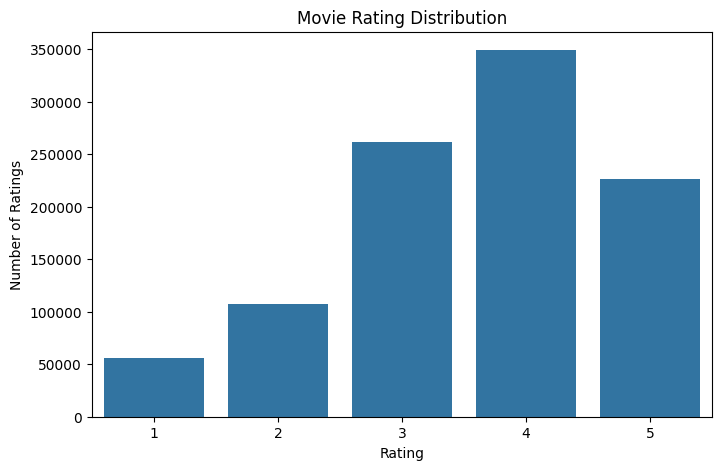

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=ratings,
    x="Rating"
)

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.show()

The rating distribution shows how frequently users assign each rating value. The distribution is not uniform, meaning some rating levels are more common than others. This is important when interpreting user preferences.

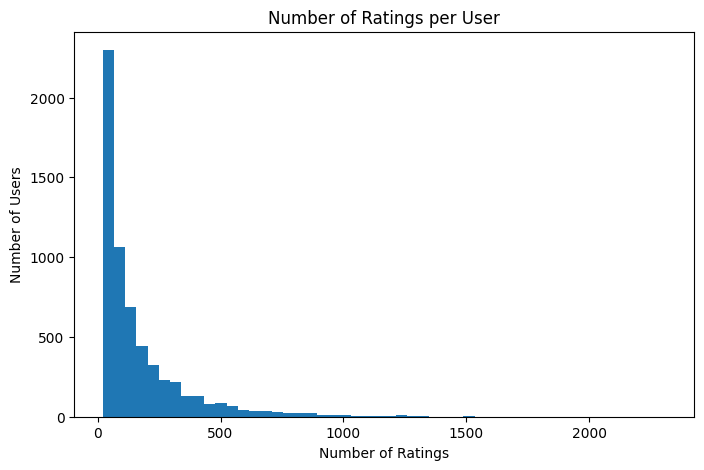

In [9]:
ratings_per_user = ratings.groupby("UserID").size()

plt.figure(figsize=(8,5))

plt.hist(
    ratings_per_user,
    bins=50
)

plt.title("Number of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.show()

Users have different levels of activity. Some users rate many movies, while others rate relatively few. This variation is important because a recommendation system needs enough information about a user to understand their preferences.

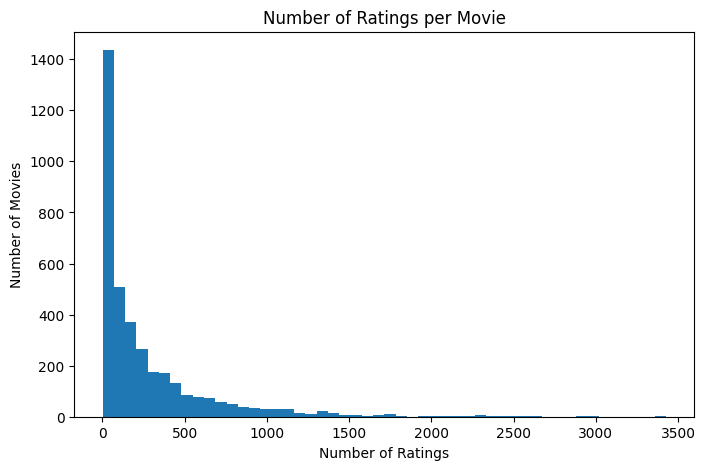

In [10]:
ratings_per_movie = ratings.groupby("MovieID").size()

plt.figure(figsize=(8,5))

plt.hist(
    ratings_per_movie,
    bins=50
)

plt.title("Number of Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")

plt.show()

Movie interactions are unevenly distributed. Some movies receive many ratings while others receive relatively few

In [11]:
top_movies = (
    ratings.groupby("MovieID")
    .agg(
        RatingCount=("Rating", "count"),
        AverageRating=("Rating", "mean")
    )
    .reset_index()
)

top_movies = top_movies.merge(
    movies[["MovieID", "Title"]],
    on="MovieID"
)

top_movies = top_movies.sort_values(
    "RatingCount",
    ascending=False
)

display(
    top_movies[
        ["Title", "RatingCount", "AverageRating"]
    ].head(10)
)

,Title,RatingCount,AverageRating
2651,American Beauty (1999),3428,4.317386
253,Star Wars: Episode IV - A New Hope (1977),2991,4.453694
1106,Star Wars: Episode V - The Empire Strikes Back...,2990,4.292977
1120,Star Wars: Episode VI - Return of the Jedi (1983),2883,4.022893
466,Jurassic Park (1993),2672,3.763847
1848,Saving Private Ryan (1998),2653,4.337354
575,Terminator 2: Judgment Day (1991),2649,4.058513
2374,"Matrix, The (1999)",2590,4.315830
1178,Back to the Future (1985),2583,3.990321
579,"Silence of the Lambs, The (1991)",2578,4.351823


The most-rated movies have substantially more interaction data than less popular movies.

In [12]:
print("Missing values in ratings:")
print(ratings.isnull().sum())

print("\nMissing values in users:")
print(users.isnull().sum())

print("\nMissing values in movies:")
print(movies.isnull().sum())

Missing values in ratings:
UserID       0
MovieID      0
Rating       0
Timestamp    0
dtype: int64

Missing values in users:
UserID        0
Gender        0
Age           0
Occupation    0
ZipCode       0
dtype: int64

Missing values in movies:
MovieID    0
Title      0
Genres     0
dtype: int64


Missing values were checked in all three datasets before modeling. This ensures that incomplete records do not unexpectedly affect feature engineering or recommendation calculations.

In [13]:
print("Duplicate ratings:", ratings.duplicated().sum())
print("Duplicate users:", users.duplicated().sum())
print("Duplicate movies:", movies.duplicated().sum())

Duplicate ratings: 0
Duplicate users: 0
Duplicate movies: 0


In [14]:
ratings = ratings.drop_duplicates()
users = users.drop_duplicates()
movies = movies.drop_duplicates()

print("Duplicate records removed.")

Duplicate records removed.


Duplicate records can cause an interaction to be counted more than once. Removing duplicates prevents duplicated observations from giving disproportionate influence to the model.

In [15]:
print("Minimum rating:", ratings["Rating"].min())
print("Maximum rating:", ratings["Rating"].max())

print(
    "Unique ratings:",
    sorted(ratings["Rating"].unique())
)

Minimum rating: 1
Maximum rating: 5
Unique ratings: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [16]:
ratings = ratings[
    (ratings["Rating"] >= 1) &
    (ratings["Rating"] <= 5)
].copy()

print("Ratings validated successfully.")

Ratings validated successfully.


The MovieLens rating scale ranges from 1 to 5. The rating values were checked and restricted to this valid range to maintain data consistency.

In [17]:
train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(train_ratings))
print("Testing records:", len(test_ratings))

Training records: 800167
Testing records: 200042


The ratings are divided into training and testing sets. The training data is used to build rating-based features, while the test data is kept separate for evaluating prediction performance.

In [18]:
movie_features = train_ratings.groupby("MovieID").agg(
    AverageRating=("Rating", "mean"),
    RatingCount=("Rating", "count")
).reset_index()

movie_features = movie_features.merge(
    movies[["MovieID", "Title", "Genres"]],
    on="MovieID",
    how="left"
)

movie_features["AverageRating"] = (
    movie_features["AverageRating"]
    .fillna(train_ratings["Rating"].mean())
)

movie_features["RatingCount"] = (
    movie_features["RatingCount"]
    .fillna(0)
)

display(movie_features.head())

,MovieID,AverageRating,RatingCount,Title,Genres
0,1,4.139606,1626,Toy Story (1995),Animation|Children's|Comedy
1,2,3.190217,552,Jumanji (1995),Adventure|Children's|Fantasy
2,3,3.035354,396,Grumpier Old Men (1995),Comedy|Romance
3,4,2.726562,128,Waiting to Exhale (1995),Comedy|Drama
4,5,3.050388,258,Father of the Bride Part II (1995),Comedy


Two useful movie-level features are created: average rating represents the historical rating level of a movie, while rating count represents how much training interaction information is available for that movie. These features are calculated only from training data to reduce data leakage.

In [19]:
movie_features["GenreList"] = (
    movie_features["Genres"]
    .str.split("|")
)

display(
    movie_features[
        ["Title", "Genres", "GenreList"]
    ].head()
)

,Title,Genres,GenreList
0,Toy Story (1995),Animation|Children's|Comedy,"[Animation, Children's, Comedy]"
1,Jumanji (1995),Adventure|Children's|Fantasy,"[Adventure, Children's, Fantasy]"
2,Grumpier Old Men (1995),Comedy|Romance,"[Comedy, Romance]"
3,Waiting to Exhale (1995),Comedy|Drama,"[Comedy, Drama]"
4,Father of the Bride Part II (1995),Comedy,[Comedy]


Movies can belong to multiple genres. Splitting the genre field allows each movie to be represented by all of its relevant genres.

In [20]:
mlb = MultiLabelBinarizer()

genre_matrix = mlb.fit_transform(
    movie_features["GenreList"]
)

genre_df = pd.DataFrame(
    genre_matrix,
    columns=mlb.classes_,
    index=movie_features.index
)

print("Genre features:")
print(list(mlb.classes_))

Genre features:
['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [21]:
movie_features_encoded = pd.concat(
    [
        movie_features[
            [
                "MovieID",
                "Title",
                "AverageRating",
                "RatingCount"
            ]
        ],
        genre_df
    ],
    axis=1
)

display(movie_features_encoded.head())

,MovieID,Title,AverageRating,RatingCount,Action,Adventure,Animation,Children's,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),4.139606,1626,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),3.190217,552,0,1,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),3.035354,396,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),2.726562,128,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Father of the Bride Part II (1995),3.050388,258,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
scaler = StandardScaler()

movie_features_encoded[
    ["AverageRating", "RatingCount"]
] = scaler.fit_transform(
    movie_features_encoded[
        ["AverageRating", "RatingCount"]
    ]
)

print("Numerical features scaled successfully.")

Numerical features scaled successfully.


Average rating and rating count have different numerical ranges. Standardization puts them on a comparable scale so that rating count does not dominate the similarity calculation simply because it has larger numerical values.

In [23]:
genre_columns = list(mlb.classes_)

content_columns = [
    "AverageRating",
    "RatingCount"
] + genre_columns

content_matrix = movie_features_encoded[
    content_columns
].values

print("Content feature matrix:")
print(content_matrix.shape)

Content feature matrix:
(3683, 20)


In [24]:
similarity_matrix = cosine_similarity(
    content_matrix
)

print(
    "Similarity matrix created:",
    similarity_matrix.shape
)

Similarity matrix created: (3683, 3683)


Each movie is represented as a numerical feature vector. Cosine similarity compares these vectors and identifies movies with similar genre and rating characteristics

In [25]:
movie_index = pd.Series(
    movie_features_encoded.index,
    index=movie_features_encoded["Title"]
)

movie_index = movie_index[
    ~movie_index.index.duplicated()
]

print("Movie index created.")

Movie index created.


In [26]:
def recommend_movies(movie_title, n=10):

    if movie_title not in movie_index:
        return pd.DataFrame({
            "Message": [
                "Movie not found."
            ]
        })

    idx = movie_index[movie_title]

    scores = similarity_matrix[idx]

    similar_indices = np.argsort(
        scores
    )[::-1]

    similar_indices = [
        i for i in similar_indices
        if i != idx
    ]

    similar_indices = similar_indices[:n]

    result = movie_features_encoded.iloc[
        similar_indices
    ][["Title"]].copy()

    result["Similarity"] = scores[
        similar_indices
    ]

    return result.reset_index(drop=True)

In [27]:
recommend_movies(
    "Toy Story (1995)",
    10
)

,Title,Similarity
0,"Bug's Life, A (1998)",0.996062
1,Toy Story 2 (1999),0.990210
2,Chicken Run (2000),0.979038
3,"South Park: Bigger, Longer and Uncut (1999)",0.961812
4,Being John Malkovich (1999),0.959610
5,Airplane! (1980),0.959384
6,Election (1999),0.957531
7,There's Something About Mary (1998),0.953977
8,American Pie (1999),0.953847
9,Clerks (1994),0.953611


The recommendation function accepts a movie title and returns the most similar movies based on the trained feature representation.

In [28]:
global_mean = train_ratings["Rating"].mean()

global_predictions = np.full(
    len(test_ratings),
    global_mean
)

global_mae = mean_absolute_error(
    test_ratings["Rating"],
    global_predictions
)

global_rmse = np.sqrt(
    mean_squared_error(
        test_ratings["Rating"],
        global_predictions
    )
)

print("Global Average Model")
print("MAE :", round(global_mae, 4))
print("RMSE:", round(global_rmse, 4))

Global Average Model
MAE : 0.936
RMSE: 1.1197


The global-average model predicts the same rating for every test interaction

In [29]:
movie_means = train_ratings.groupby(
    "MovieID"
)["Rating"].mean()

movie_predictions = (
    test_ratings["MovieID"]
    .map(movie_means)
)

movie_predictions = movie_predictions.fillna(
    global_mean
)

movie_mae = mean_absolute_error(
    test_ratings["Rating"],
    movie_predictions
)

movie_rmse = np.sqrt(
    mean_squared_error(
        test_ratings["Rating"],
        movie_predictions
    )
)

print("Movie Average Model")
print("MAE :", round(movie_mae, 4))
print("RMSE:", round(movie_rmse, 4))

Movie Average Model
MAE : 0.7852
RMSE: 0.9824


The movie-average model predicts ratings using each movie's average training rating

In [30]:
comparison = pd.DataFrame({
    "Model": [
        "Global Average",
        "Movie Average"
    ],
    "MAE": [
        global_mae,
        movie_mae
    ],
    "RMSE": [
        global_rmse,
        movie_rmse
    ]
})

display(comparison)

,Model,MAE,RMSE
0,Global Average,0.935987,1.119729
1,Movie Average,0.785189,0.982407


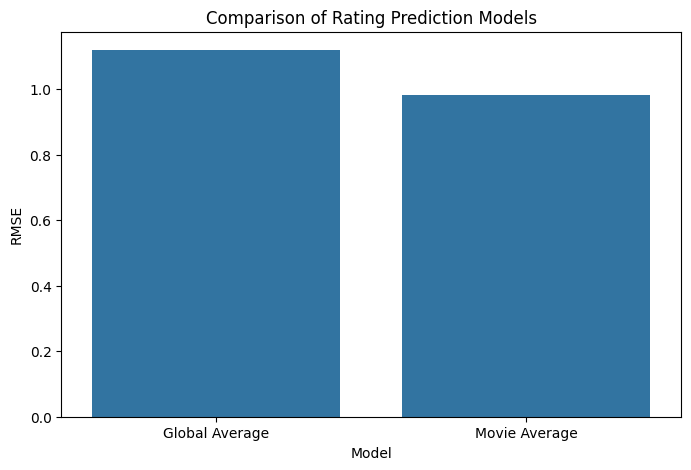

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE"
)

plt.title("Comparison of Rating Prediction Models")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.show()

The two baseline models are compared using MAE and RMSE. Lower values represent smaller rating-prediction errors. The comparison provides a quantitative baseline for the recommendation project.

In [32]:
test_movie = "Toy Story (1995)"

recommendations = recommend_movies(
    test_movie,
    10
)

print("Recommendations for:", test_movie)

display(recommendations)

Recommendations for: Toy Story (1995)


,Title,Similarity
0,"Bug's Life, A (1998)",0.996062
1,Toy Story 2 (1999),0.990210
2,Chicken Run (2000),0.979038
3,"South Park: Bigger, Longer and Uncut (1999)",0.961812
4,Being John Malkovich (1999),0.959610
5,Airplane! (1980),0.959384
6,Election (1999),0.957531
7,There's Something About Mary (1998),0.953977
8,American Pie (1999),0.953847
9,Clerks (1994),0.953611


The final test demonstrates that the trained system can take a known movie and produce a ranked list of similar movies

In [33]:
model_package = {
    "movie_features": movie_features_encoded,
    "similarity_matrix": similarity_matrix,
    "movie_index": movie_index,
    "mlb": mlb,
    "scaler": scaler
}

joblib.dump(
    model_package,
    "movie_recommendation_model.pkl"
)

print(
    "Saved as movie_recommendation_model.pkl"
)

Saved as movie_recommendation_model.pkl


In [34]:
print(
    "Model file exists:",
    os.path.exists(
        "movie_recommendation_model.pkl"
    )
)

Model file exists: True


In [39]:
saved_model = joblib.load(
    "movie_recommendation_model.pkl"
)

loaded_movies = saved_model["movie_features"]
loaded_similarity = saved_model["similarity_matrix"]
loaded_movie_index = saved_model["movie_index"]

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [40]:
def recommend_from_saved_model(movie_title, n=10):

    if movie_title not in loaded_movie_index:
        return pd.DataFrame({
            "Message": [
                "Movie not found."
            ]
        })

    idx = loaded_movie_index[movie_title]

    scores = loaded_similarity[idx]

    indices = np.argsort(
        scores
    )[::-1]

    indices = [
        i for i in indices
        if i != idx
    ][:n]

    result = loaded_movies.iloc[
        indices
    ][["Title"]].copy()

    result["Similarity"] = scores[indices]

    return result.reset_index(drop=True)

In [41]:
recommend_from_saved_model(
    "Toy Story (1995)",
    10
)

,Title,Similarity
0,"Bug's Life, A (1998)",0.996062
1,Toy Story 2 (1999),0.990210
2,Chicken Run (2000),0.979038
3,"South Park: Bigger, Longer and Uncut (1999)",0.961812
4,Being John Malkovich (1999),0.959610
5,Airplane! (1980),0.959384
6,Election (1999),0.957531
7,There's Something About Mary (1998),0.953977
8,American Pie (1999),0.953847
9,Clerks (1994),0.953611


The saved model can be loaded and used to generate recommendations successfully. This confirms that the model-saving process is functional and that the system can be reused for deployment.